### uses the activation of AL neurons to generate different activity patterns in MB

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def AL_LIF_STDP(I_AL):

    # ----------------------------
    # LIF PARAMETERS
    # ----------------------------
    V_rest = -84.0
    V_thresh = -25.8
    V_recov = -40.2
    V_spike = 9.5
    g_leak = 0.2
    C = 1.0

    dt = 0.5
    K = 1000

    N = len(I_AL)   # number of LIF neurons = number of AL neurons

    # ----------------------------
    # STATE VARIABLES
    # ----------------------------
    V = np.full((K, N), V_rest)

    # AL activity (static input in this version)
    A = np.array(I_AL).reshape(1, N)
    print(A)

    # synaptic weights AL → LIF (matrix)
    W = np.random.normal(6, 2, (N, N))
    print(W)

    # spike record
    S = np.zeros((K, N))

    # learning params
    eta = 0.01
    lam = 0.001

    error = np.zeros(K)

    # ----------------------------
    # TIME LOOP
    # ----------------------------
    for k in range(K-1):

        # ----------------------------
        # SYNAPTIC INPUT (UPGRADED)
        # ----------------------------
        I_trace = np.zeros((K, N))
        I_input = (W @ A.T).flatten()
        I_trace[k] = I_input
        # ----------------------------
        # LIF DYNAMICS
        # ----------------------------
        dV = (-g_leak * (V[k] - V_rest) + I_input) / C
        V[k+1] = V[k] + dt * dV

        # ----------------------------
        # SPIKING
        # ----------------------------
        spiking = V[k] >= V_thresh
        S[k] = spiking.astype(float)

        V[k, spiking] = V_spike
        V[k+1, spiking] = V_recov

        # ----------------------------
        # STDP-LIKE UPDATE (DISCRETE)
        # ----------------------------
        # pre (AL) × post (LIF spike)
        for i in range(N):
            for j in range(N):
                active_AL = A[0]  # binary vector
                if np.sum(active_AL) > 0:
                    W += eta * np.outer(S[k], active_AL)

        # decay
        W *= (1 - lam)

        # ----------------------------
        # ERROR (optional tracking)
        # ----------------------------
        error[k] = np.mean(np.abs(S[k] - A))

    return V, W, S, error, I_trace


### Plots previous cell

[0, 1, 1, 0, 0]
[[0 1 1 0 0]]
[[ 6.08953027  3.33486591 10.35500986  6.81222004  3.86909716]
 [ 4.56462076  8.61940493  7.94427847  7.60027144  4.84699888]
 [10.12258673  5.35363448 10.05498808  9.18437719  5.83425699]
 [ 9.04359264 10.61985964  4.64669063  4.94418109  7.02127765]
 [ 5.86981327  4.84257251  3.46166945  5.64284865  5.05011646]]


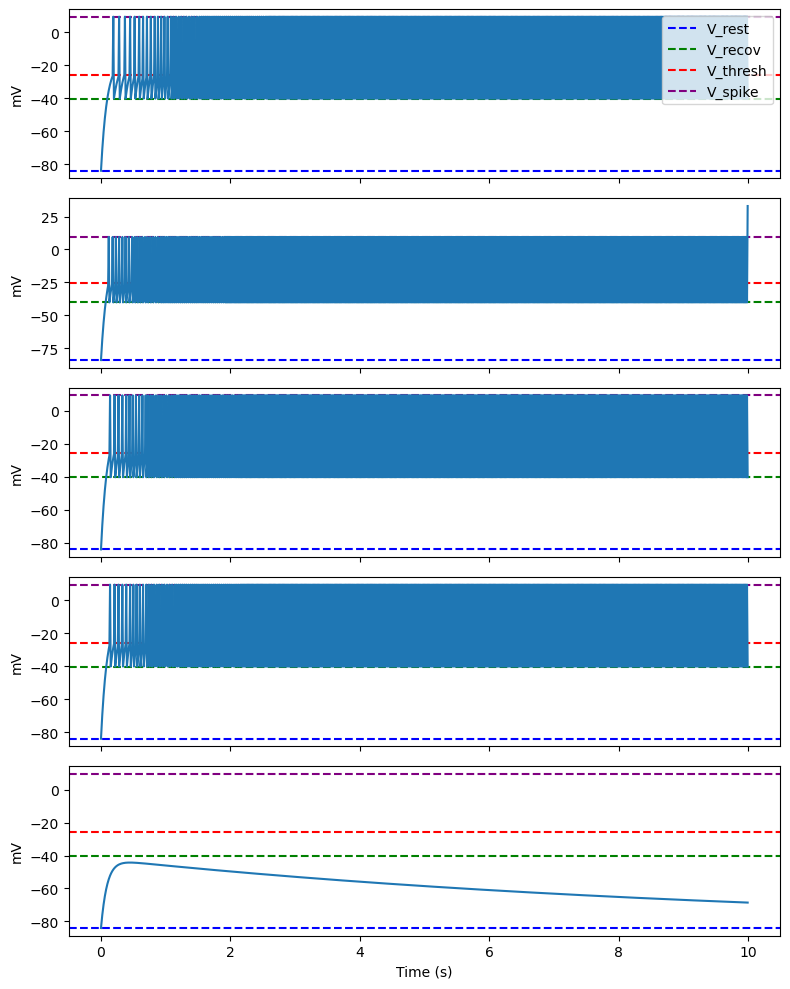

In [20]:
Odor = [0,1,1,0,0]
I_AL = Odor
print(I_AL)

V, W, S, error,I_trace = AL_LIF_STDP(I_AL)

t = np.arange(V.shape[0]) * 0.01

fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

for i in range(5):
    ax = axes[i]

    # horizontal reference lines
    ax.axhline(V_rest, color='b', linestyle='--', label='V_rest')
    ax.axhline(V_recov, color='g', linestyle='--', label='V_recov')
    ax.axhline(V_thresh, color='r', linestyle='--', label='V_thresh')
    ax.axhline(V_spike, color='purple', linestyle='--', label='V_spike')

    # membrane potential trace
    ax.plot(t, V[:, i])
    ax.set_ylabel("mV")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### weights updated per timestep

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def AL_LIF_STDP(I_AL):

    # ----------------------------
    # LIF PARAMETERS
    # ----------------------------
    V_rest = -84.0
    V_thresh = -25.8
    V_recov = -40.2
    V_spike = 9.5
    g_leak = 0.2
    C = 1.0

    dt = 0.5
    K = 1000

    N = len(I_AL)   # number of LIF neurons

    # ----------------------------
    # STATE VARIABLES
    # ----------------------------
    V = np.full((K, N), V_rest)

    # AL activity (static input in this version)
    A = np.array(I_AL).reshape(1, N)
    print(A)

    # synaptic weights AL → LIF (matrix)
    W = np.random.normal(7, 2, (N, N))
    print(W)

    # spike record
    S = np.zeros((K, N))

    # learning params
    eta = 0.01
    lam = 0.001

    error = np.zeros(K)

    # ----------------------------
    # TIME LOOP
    # ----------------------------
    for k in range(K-1):

        # ----------------------------
        # SYNAPTIC INPUT (UPGRADED)
        # ----------------------------
        A_T = np.tile(I_AL, (K, 1))   # (time × neurons)
        I_trace = np.zeros((K, N))
        I_input = W @ A_T[k]
        I_trace[k] = I_input
        # ----------------------------
        # LIF DYNAMICS
        # ----------------------------
        dV = (-g_leak * (V[k] - V_rest) + I_input) / C
        V[k+1] = V[k] + dt * dV

        # ----------------------------
        # SPIKING
        # ----------------------------
        spiking = V[k] >= V_thresh
        S[k] = spiking.astype(float)

        V[k, spiking] = V_spike
        V[k+1, spiking] = V_recov
        
        W += eta * np.outer(S[k], A_T[k])

        # decay
        W *= (1 - lam)

        # ----------------------------
        # ERROR (optional tracking)
        # ----------------------------
        error[k] = np.mean(np.abs(S[k] - A))

    return V, W, S, error, I_trace,A_T, V_rest,V_thresh, V_recov, V_spike, N


### plot previous cell

[0, 1, 0, 1, 0]
[[0 1 0 1 0]]
[[ 3.95764369  9.37293523  5.82340923  9.12628553  7.37950434]
 [ 6.46799154  5.76239232 10.73868156  8.41207189  6.67927694]
 [ 8.84185188  8.34890057  6.47329748  9.53394111 10.89304389]
 [ 5.48533984  6.51579102  7.7868331   3.92684386  7.03004518]
 [ 5.04889303  6.46118811  9.85985444  7.72193731  6.01395669]]


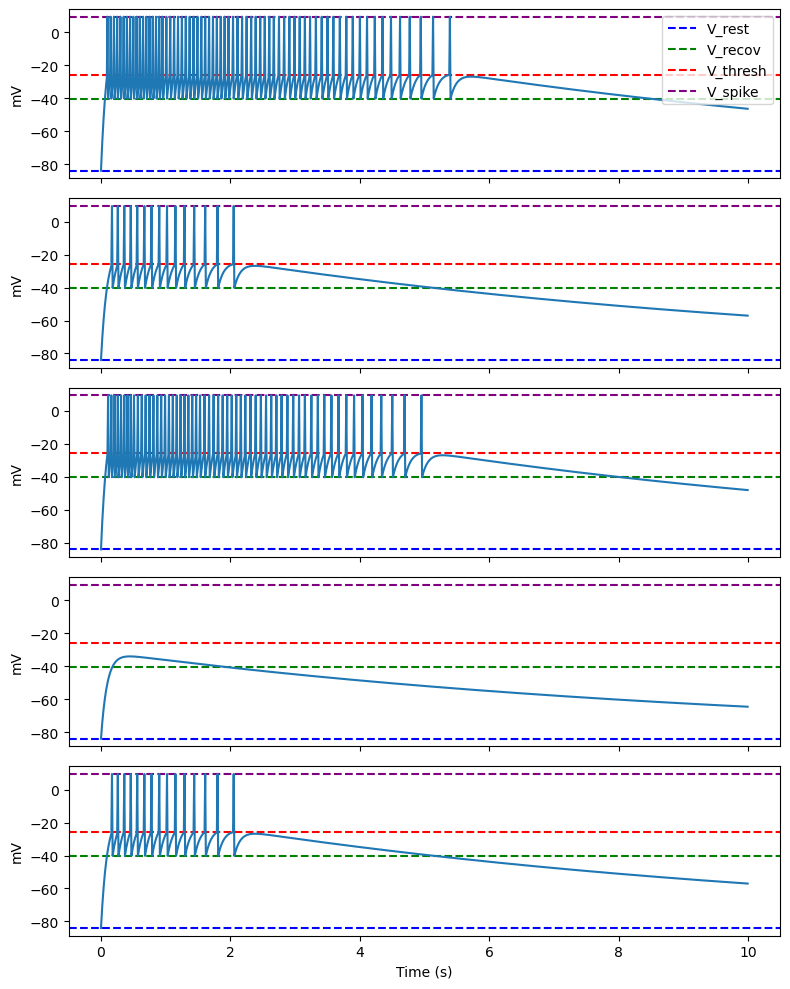

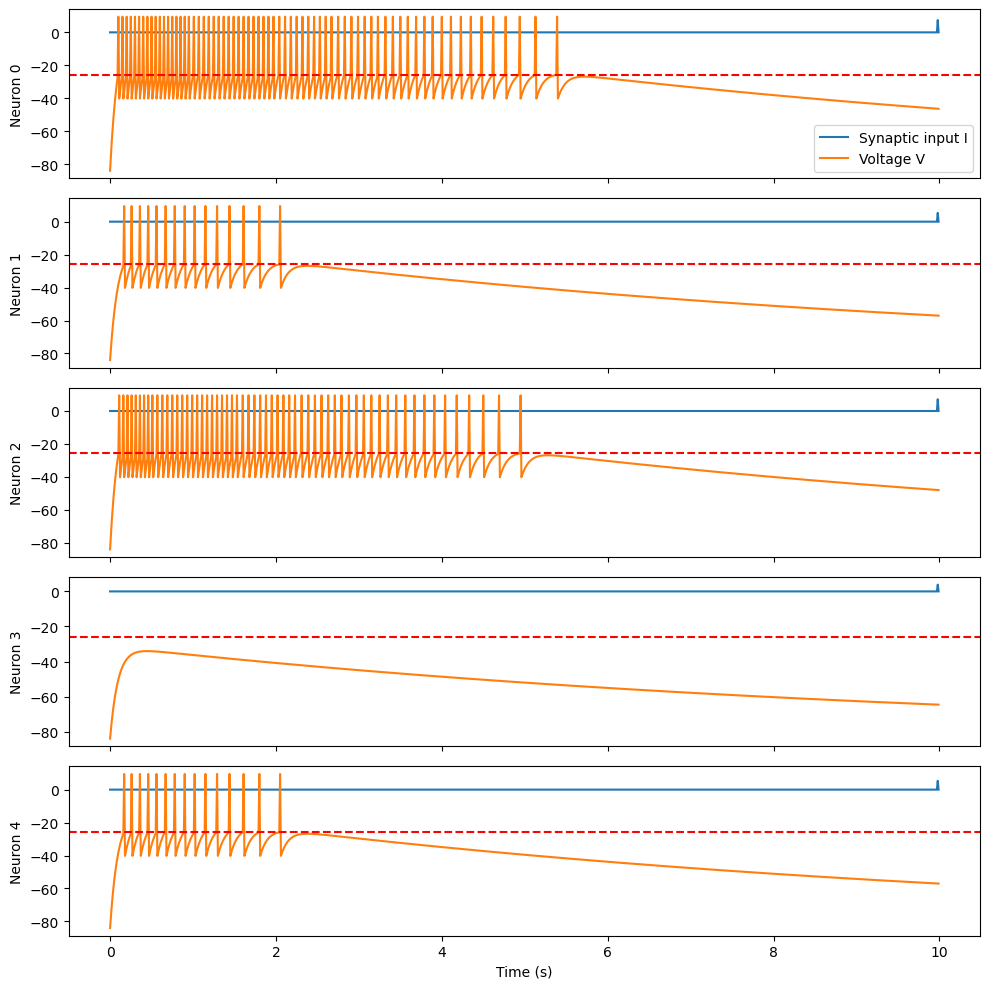

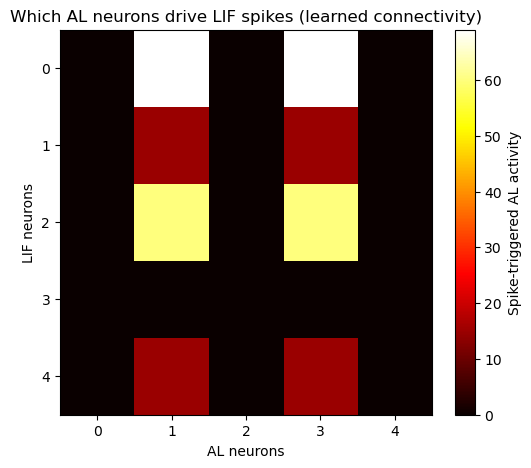

In [26]:
Odor1 = [0,1,1,0,0]
Odor2 = [0,1,0,1,0]
I_AL = Odor2
print(I_AL)

V, W, S, error, I_trace,A_T, V_rest,V_thresh, V_recov, V_spike,N = AL_LIF_STDP(I_AL)

t = np.arange(V.shape[0]) * 0.01

fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

for i in range(5):
    ax = axes[i]

    # horizontal reference lines
    ax.axhline(V_rest, color='b', linestyle='--', label='V_rest')
    ax.axhline(V_recov, color='g', linestyle='--', label='V_recov')
    ax.axhline(V_thresh, color='r', linestyle='--', label='V_thresh')
    ax.axhline(V_spike, color='purple', linestyle='--', label='V_spike')

    # membrane potential trace
    ax.plot(t, V[:, i])
    ax.set_ylabel("mV")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

for i in range(5):
    ax = axes[i]

    ax.plot(t, I_trace[:, i], label="Synaptic input I")
    ax.plot(t, V[:, i], label="Voltage V")

    ax.axhline(V_thresh, linestyle='--', color='red')

    ax.set_ylabel(f"Neuron {i}")

axes[0].legend()
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

pre_spike_drive = np.zeros((N, N))

for t in range(S.shape[0]):
    pre_spike_drive += np.outer(S[t], A_T[t])

plt.figure(figsize=(6, 5))
plt.imshow(pre_spike_drive, cmap='hot', aspect='auto')
plt.colorbar(label="Spike-triggered AL activity")
plt.xlabel("AL neurons")
plt.ylabel("LIF neurons")
plt.title("Which AL neurons drive LIF spikes (learned connectivity)")
plt.show()

### attempts to relate trials to updating weight matrix 

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def AL_LIF_STDP(I_AL):

    # ----------------------------
    # LIF PARAMETERS
    # ----------------------------
    V_rest = -84.0
    V_thresh = -25.8
    V_recov = -40.2
    V_spike = 9.5
    g_leak = 0.2
    C = 1.0

    dt = 0.5
    K = 1000
    N = len(I_AL)

    # ----------------------------
    # INPUT (fixed across trials)
    # ----------------------------
    A_T = np.tile(I_AL, (K, 1))   # (time × neurons)

    # ----------------------------
    # INITIAL WEIGHTS
    # ----------------------------
    W = np.random.normal(7, 2, (N, N))

    # learning params
    eta = 0.01
    lam = 0.001

    # ----------------------------
    # TRIAL SETUP
    # ----------------------------
    n_trials = 50
    trial_schedule = np.array([1]*25 + [0]*25)  # learn then extinct

    W_history = []

    # ============================
    # TRIAL LOOP
    # ============================
    for trial in range(n_trials):
        S_history = []
        # reset state each trial
        V = np.full((K, N), V_rest)
        S = np.zeros((K, N))
        I_trace = np.zeros((K, N))

        reward = +1 if trial_schedule[trial] == 1 else -1
        S_history.append(S.copy())
        # ----------------------------
        # TIME LOOP
        # ----------------------------
        for k in range(K-1):

            # synaptic input
            I_input = W @ A_T[k]
            I_trace[k] = I_input

            # LIF dynamics
            dV = (-g_leak * (V[k] - V_rest) + I_input) / C
            V[k+1] = V[k] + dt * dV

            # spiking
            spiking = V[k] >= V_thresh
            S[k] = spiking.astype(float)

            V[k, spiking] = V_spike
            V[k+1, spiking] = V_recov

            # ----------------------------
            # TRIAL-BASED LEARNING
            # ----------------------------
            W += eta * reward * np.outer(S[k] + 0.1, A_T[k])

            # decay
            #W *= (1 - lam)

        # store weights after each trial
        W_history.append(W.copy())

    W_history = np.array(W_history)

    return W_history, S_history, V, I_trace, V_rest, V_thresh, V_recov, V_spike

### Plots previous cell

[0, 1, 0, 1, 0]


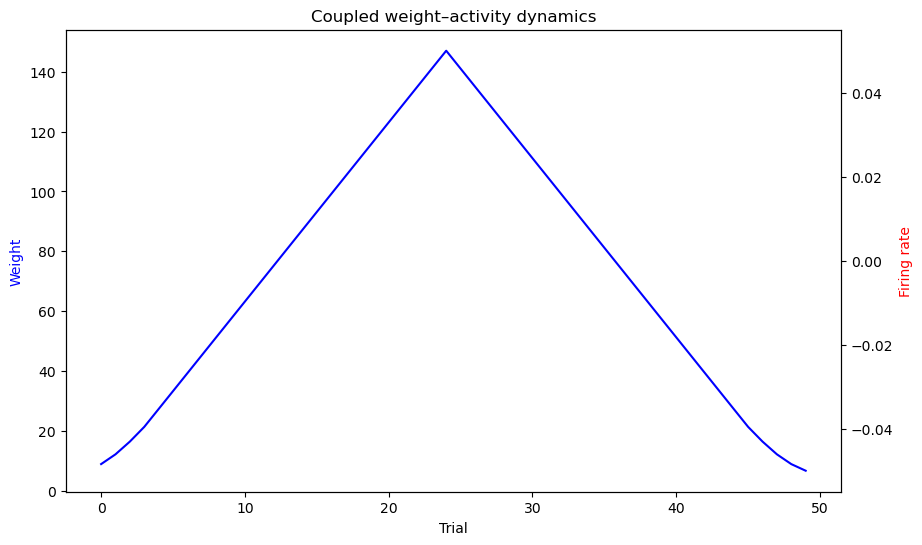

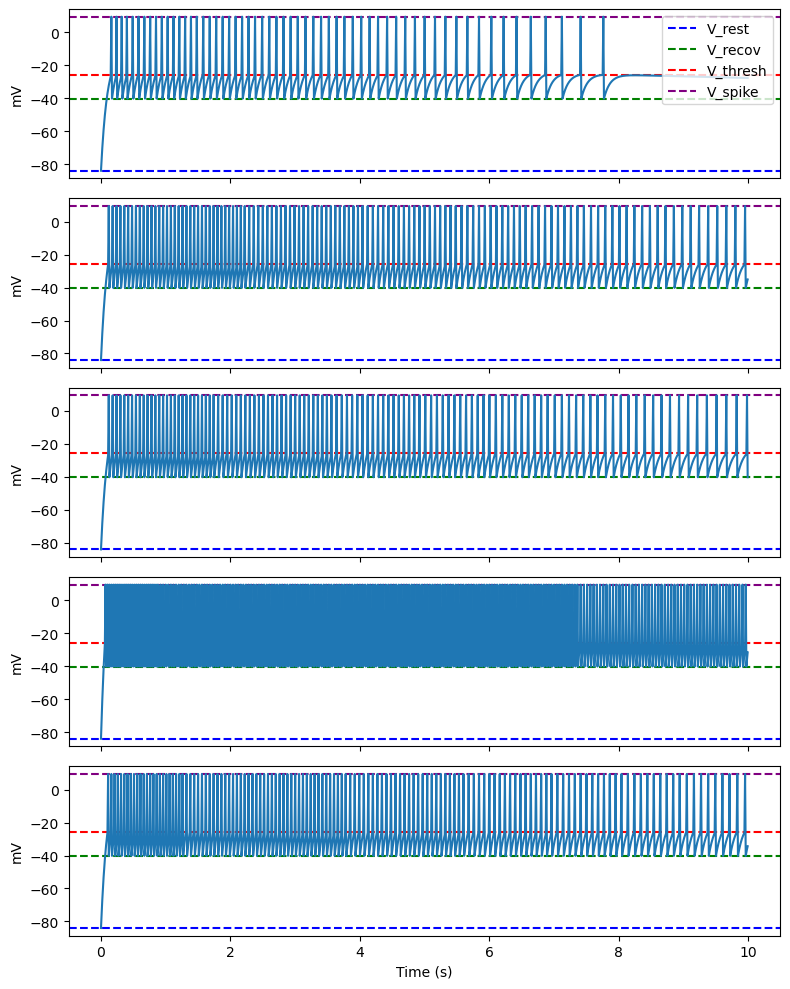

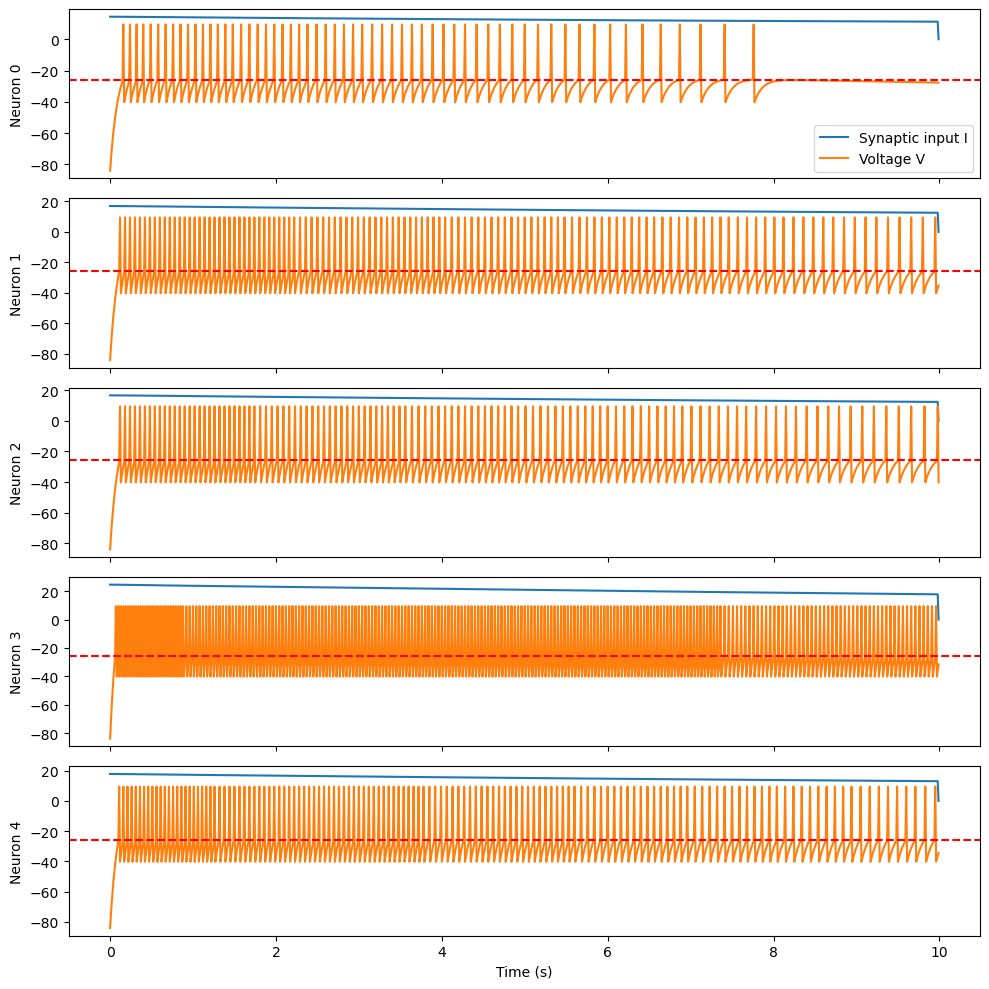

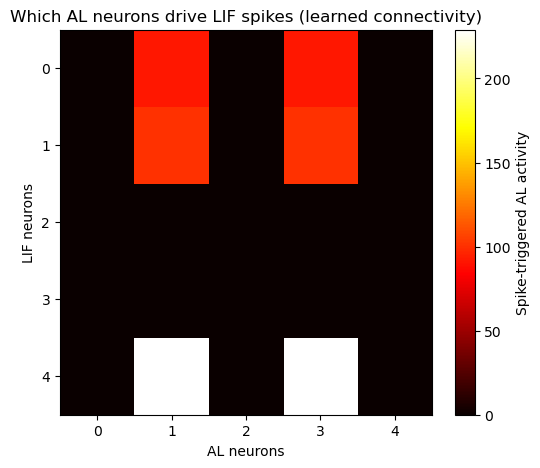

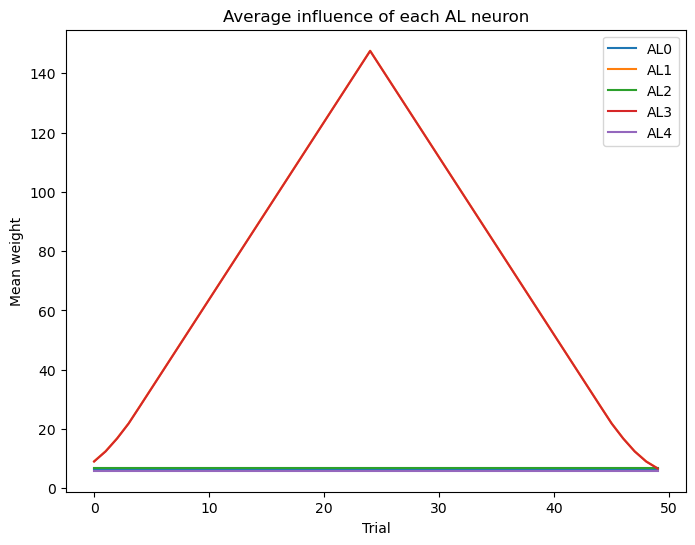

In [45]:
Odor1 = [0,1,1,0,0]
Odor2 = [0,1,0,1,0]
I_AL = Odor2
print(I_AL)

W_history, S_history, V, I_trace, V_rest, V_thresh, V_recov, V_spike = AL_LIF_STDP(I_AL)
S_history = np.array(S_history)   # (trials, time, neurons)
spike_rate = S_history.mean(axis=1)   # shape: (trials, neurons)

fig, ax1 = plt.subplots(figsize=(10,6))

neuron_idx = 1

# weights
ax1.plot(W_history[:, neuron_idx, 1], 'b', label="Weight")
ax1.set_ylabel("Weight", color='b')

# firing
ax2 = ax1.twinx()
ax2.plot(spike_rate[:, neuron_idx], 'r--', label="Firing rate")
ax2.set_ylabel("Firing rate", color='r')

ax1.set_xlabel("Trial")
plt.title("Coupled weight–activity dynamics")

plt.show()


t = np.arange(V.shape[0]) * 0.01

fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

for i in range(5):
    ax = axes[i]

    # horizontal reference lines
    ax.axhline(V_rest, color='b', linestyle='--', label='V_rest')
    ax.axhline(V_recov, color='g', linestyle='--', label='V_recov')
    ax.axhline(V_thresh, color='r', linestyle='--', label='V_thresh')
    ax.axhline(V_spike, color='purple', linestyle='--', label='V_spike')

    # membrane potential trace
    ax.plot(t, V[:, i])
    ax.set_ylabel("mV")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

for i in range(5):
    ax = axes[i]

    ax.plot(t, I_trace[:, i], label="Synaptic input I")
    ax.plot(t, V[:, i], label="Voltage V")

    ax.axhline(V_thresh, linestyle='--', color='red')

    ax.set_ylabel(f"Neuron {i}")

axes[0].legend()
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

pre_spike_drive = np.zeros((N, N))

for t in range(S.shape[0]):
    pre_spike_drive += np.outer(S[t], A_T[t])

plt.figure(figsize=(6, 5))
plt.imshow(pre_spike_drive, cmap='hot', aspect='auto')
plt.colorbar(label="Spike-triggered AL activity")
plt.xlabel("AL neurons")
plt.ylabel("LIF neurons")
plt.title("Which AL neurons drive LIF spikes (learned connectivity)")
plt.show()